# WD Classification primer

In the following notebook we'll take a look at processing the label information from the spectroscopic classification campaign of SDSS, of around 23000 v6_0_2 BOSS spectra obtained for the mwm_wd and mwm_cb cartons. 

After that, we'll go into the processing of the associated .dat files, building a data processing pipeline and a machine learning model.

First, we must download the label informartion which is hosted on a google drive folder, and consists of several .csv files. We've saved the files on a local folder which is represented in the variable "path" of the next cell. Some excel duplicates where found and manually removed from the folder. Now, we can gather the desired "fields" or columns from all this files and merge them into a pandas dataframe.

In [1]:
import os
import pandas as pd

path = r'C:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\NPF\LabeledData\csv'
fields = ['File Name', 'MJD', 'Target ID', 'DB ID' ,'Classification', 'Data Quality']

raw_labels_df = pd.DataFrame()

# We import all of the csv files and merge them in star_df

for filename in os.listdir(path):
    file_path = os.path.join(path, filename)
    df = pd.read_csv (file_path, usecols=fields)
    raw_labels_df = raw_labels_df.append(df, ignore_index=True)
print(raw_labels_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35253 entries, 0 to 35252
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Classification  35253 non-null  object
 1   DB ID           35253 non-null  int64 
 2   Data Quality    11158 non-null  object
 3   File Name       35253 non-null  object
 4   MJD             35253 non-null  int64 
 5   Target ID       35253 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 1.6+ MB
None


In [2]:
raw_labels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,NaN,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,sdX,23360,BLEND,spec-15301-59338-04602344336-23360.png,59338,4602344336
2,WDA,18900,SNR,spec-15113-59217-04538755416-18900.png,59217,4538755416
3,WDA,18575,NaN,spec-15086-59267-04474143209-18575.png,59267,4474143209
4,WD,20528,SNR,spec-15198-59269-04351438385-20528.png,59269,4351438385
...,...,...,...,...,...,...
35248,WDA,15895,SNR,spec-15011-59222-04399876473-15895.png,59222,4399876473
35249,WDA,20605,NaN,spec-15200-59324-04589320996-20605.png,59324,4589320996
35250,WDA,19388,NaN,spec-15193-59243-04594923329-19388.png,59243,4594923329
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


We can see there is some NaN values when no data quality comment was offered. For now, let's assume this data can be considererd OK. 

Let's take a look at the label distribution.

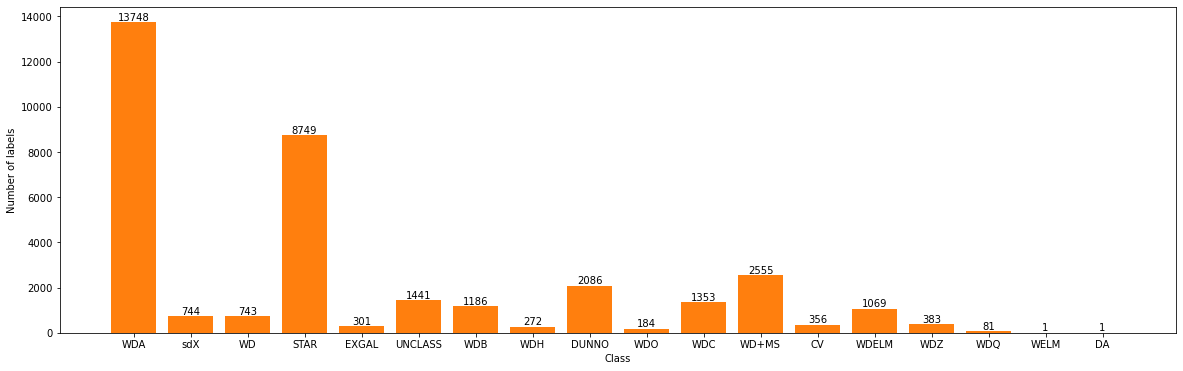

In [3]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Plot bar graph of labels

counter = Counter(raw_labels_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can see there's probably to mislabeled elements, WELM and DA. We can make the tag correction now.

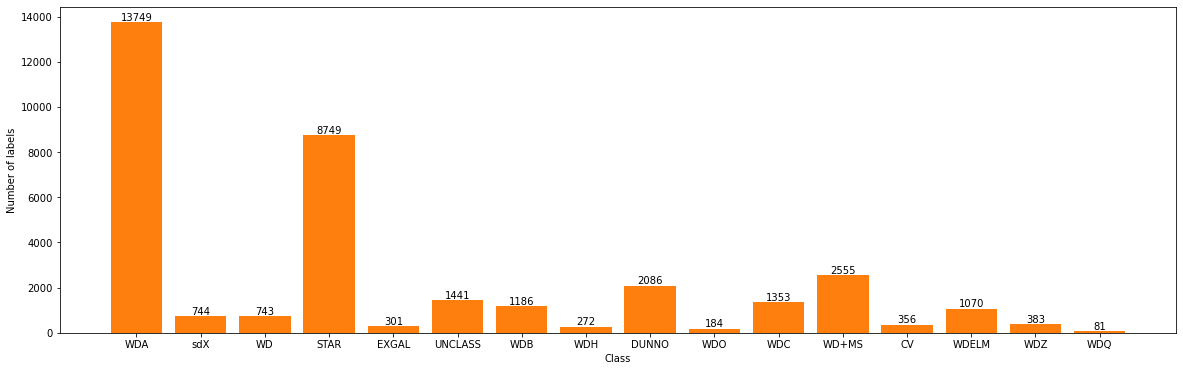

In [4]:
raw_labels_df.loc[raw_labels_df['Classification'] == 'WELM', 'Classification'] = 'WDELM'
raw_labels_df.loc[raw_labels_df['Classification'] == 'DA', 'Classification'] = 'WDA'


# Changing the NaNs data quality abscence of comment with an 'OK'

raw_labels_df['Data Quality'] = raw_labels_df['Data Quality'].fillna('OK')

# Plot bar graph of labels

counter = Counter(raw_labels_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can know check the Data quality comments distribution

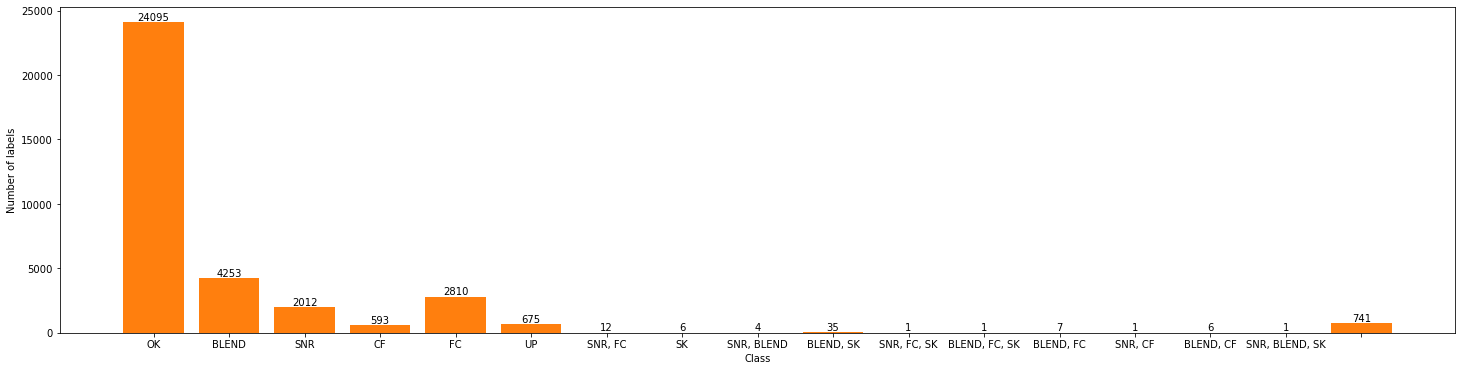

In [5]:
counter = Counter(raw_labels_df['Data Quality'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star Data Quality Comments using matplotlib

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(25,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can obersve that, on the one side, there's multiple Data Quality Comments for a star minority, and that there is a misterious blank comment, different from 'OK' (Previously NaNs). This Tags should probably labeled as OK too.

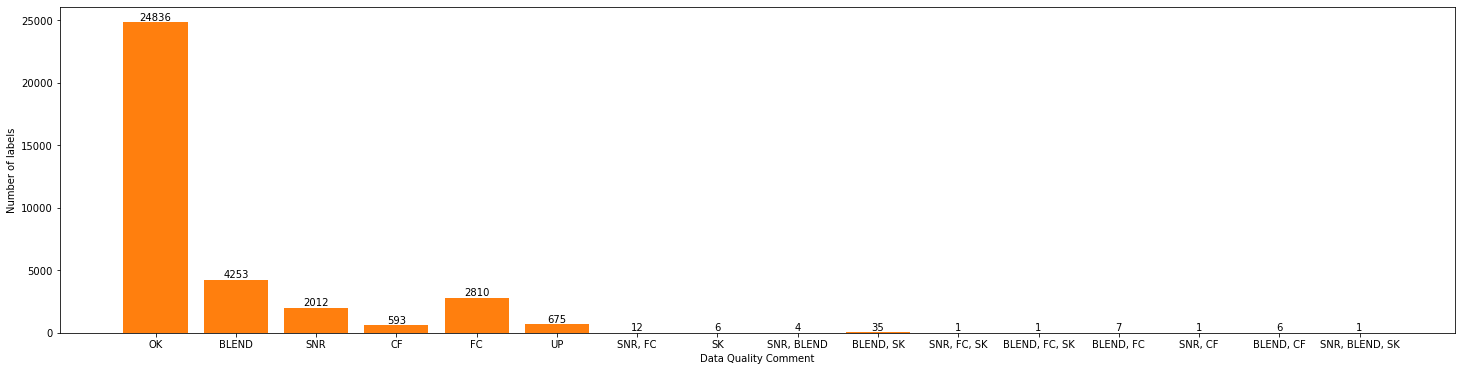

In [6]:
raw_labels_df.loc[raw_labels_df['Data Quality'] == ' ', 'Data Quality'] = 'OK'

counter = Counter(raw_labels_df['Data Quality'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star Data Quality Comments using matplotlib

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(25,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Data Quality Comment')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

Next, we'd like to find out how many of the same stellar objects are actually labeled, not counting repetitions for different observations.

In [7]:
target_id = raw_labels_df['Target ID']

# Duplicated values are marked as True, except the first element found, which is kept as False.

target_id.duplicated(keep='first').value_counts()

True     25349
False     9904
Name: Target ID, dtype: int64

So, there's actually 9904 unique stellar elements whit multiple observations, and thus, Data Quality Comments and Classifications may vary between each observation. This means we need to define a way to parse this data for the following ML algorithms. Let's explore a particular random element.

In [8]:
# Get data drom element with target ID 4342114705 

raw_labels_df.loc[raw_labels_df['Target ID'] == 4342114705]

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
4158,STAR,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
25514,STAR,19161,OK,spec-15121-59212-04342114705-19161.png,59212,4342114705
29241,DUNNO,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
33146,STAR,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


In [9]:
# Let's look at element 5369272434 as an example

raw_labels_df.loc[raw_labels_df['Target ID'] == 5369272434]

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
6861,WDA,24480,FC,spec-15332-59305-05369272434-24480.png,59305,5369272434
17754,sdX,24480,CF,spec-15332-59305-05369272434-24480.png,59305,5369272434


### Pre-processing Label information

Now we can focuse on an approach to pre-process label information for the upcoming ML algorithms. On a first thought, i wrote the following routine excludes all stellar objects not marked with at leats one 'OK' in it's observations, and only if there are more than 80% of OK observations. This is probably WRONG but left here for discussion.

In [10]:
# Routine to define elements to remove from pandas data frame based on Data Quality Note. Element's Target ID is stored in to_remove list.
# target_id = raw_labels_df['Target ID']
# to_remove = []
# for id in target_id.unique():
#     tid = target_id[target_id == id].index.to_list()
#     element_df  = raw_labels_df.iloc[tid]
#     if 'OK' in element_df['Data Quality'].value_counts().keys():
#         if element_df['Data Quality'].value_counts()['OK'] / element_df['Data Quality'].value_counts().sum() < 0.8 :
#             to_remove.append(id)
#     else:
#         to_remove.append(id)
# star_df_DQ = star_df.copy()

# Define new data frame with removed columns
# for id in to_remove:
#     star_df_DQ.drop(star_df_DQ.index[star_df_DQ['Target ID'] == id], inplace=True)
# star_df_DQ.info()

The approach i take here is to exclude only the label observations (and thus, also the corresponding .dat file for each) which data quality comment is other than 'OK'. 

In [11]:
qlabels_df = raw_labels_df.copy()

qlabels_df.drop(qlabels_df[qlabels_df['Data Quality'] != 'OK'].index, inplace = True)

In [12]:
qlabels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
5,WDA,22243,OK,spec-15266-59306-04592699543-22243.png,59306,4592699543
6,WDA,19555,OK,spec-15165-59202-04545012720-19555.png,59202,4545012720
7,WD,20892,OK,spec-15221-59245-04306649216-20892.png,59245,4306649216
...,...,...,...,...,...,...
35242,STAR,20434,OK,spec-15288-59294-04552877469-20434.png,59294,4552877469
35244,STAR,20259,OK,spec-15195-59271-04543081849-20259.png,59271,4543081849
35246,STAR,20046,OK,spec-15285-59304-04550841319-20046.png,59304,4550841319
35249,WDA,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996


In [13]:
# Let's explore how many unique stellar objects we have left.

qlabels_df['Target ID'].duplicated(keep='first').value_counts()

True     16723
False     8113
Name: Target ID, dtype: int64

In [14]:
# Let's look at element 4553795050 as an example.

qlabels_df.loc[qlabels_df['Target ID'] == 4553795050]

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
4234,WDB,19293,OK,spec-15127-59190-04553795050-19293.png,59190,4553795050
12013,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050
17274,WDA,19293,OK,spec-15190-59273-04553795050-19293.png,59273,4553795050
18200,WDB,19293,OK,spec-15127-59219-04553795050-19293.png,59219,4553795050
19215,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050
28327,WDB,19293,OK,spec-15127-59219-04553795050-19293.png,59219,4553795050
33724,WDC,19293,OK,spec-15190-59273-04553795050-19293.png,59273,4553795050
34566,WDB,19293,OK,spec-15190-59267-04553795050-19293.png,59267,4553795050
34673,WDB,19293,OK,spec-15127-59190-04553795050-19293.png,59190,4553795050
35240,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050


Now, we can focus on how to resolve the fact that a same object can have several different classification labels. One option could be to consider the official classification Label as the most voted one, resolving ties to either way.

In [15]:
# The following statement will return most applied label for each element, given the target ID field, as a one dimensional list.

qlabels_df.loc[qlabels_df['Target ID'] == 4553795050]['Classification'].mode().to_list()

['WDB']

For simplicity, in this first run, let's decide to use only one of the observations which will have to be the same as the mode for the object. We will pick any observation and create a new dataframe.

In [16]:
star_df = pd.DataFrame()

for object_id in qlabels_df['Target ID'].unique():
    mode_class = qlabels_df.loc[qlabels_df['Target ID'] == object_id]['Classification'].mode().to_list()[0]
    star_df = star_df.append(qlabels_df.loc[(qlabels_df['Classification'] == mode_class) & (qlabels_df['Target ID'] == object_id)].iloc[0])

In [17]:
star_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8113 entries, 0 to 35229
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Classification  8113 non-null   object 
 1   DB ID           8113 non-null   float64
 2   Data Quality    8113 non-null   object 
 3   File Name       8113 non-null   object 
 4   MJD             8113 non-null   float64
 5   Target ID       8113 non-null   float64
dtypes: float64(3), object(3)
memory usage: 443.7+ KB


In [18]:
star_df = star_df.reset_index(drop=True)
star_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899.0,OK,spec-15249-59265-04601916346-21899.png,59265.0,4.601916e+09
1,WDA,18575.0,OK,spec-15086-59267-04474143209-18575.png,59267.0,4.474143e+09
2,WDA,22243.0,OK,spec-15266-59306-04592699543-22243.png,59306.0,4.592700e+09
3,WDA,19555.0,OK,spec-15165-59202-04545012720-19555.png,59202.0,4.545013e+09
4,WD,20892.0,OK,spec-15221-59245-04306649216-20892.png,59245.0,4.306649e+09
...,...,...,...,...,...,...
8108,WD+MS,25029.0,OK,spec-15346-59300-05208867797-25029.png,59300.0,5.208868e+09
8109,WDC,17158.0,OK,spec-15034-59165-04382235429-17158.png,59165.0,4.382235e+09
8110,STAR,20417.0,OK,spec-15288-59294-04552859261-20417.png,59294.0,4.552859e+09
8111,STAR,25989.0,OK,spec-15370-59338-04347784790-25989.png,59338.0,4.347785e+09


We notice the int64 columns where changed to floats during the process, let's convert them back

In [19]:
star_df = star_df.astype({"DB ID": 'int64', "MJD": 'int64', "Target ID" : 'int64'})
star_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
2,WDA,22243,OK,spec-15266-59306-04592699543-22243.png,59306,4592699543
3,WDA,19555,OK,spec-15165-59202-04545012720-19555.png,59202,4545012720
4,WD,20892,OK,spec-15221-59245-04306649216-20892.png,59245,4306649216
...,...,...,...,...,...,...
8108,WD+MS,25029,OK,spec-15346-59300-05208867797-25029.png,59300,5208867797
8109,WDC,17158,OK,spec-15034-59165-04382235429-17158.png,59165,4382235429
8110,STAR,20417,OK,spec-15288-59294-04552859261-20417.png,59294,4552859261
8111,STAR,25989,OK,spec-15370-59338-04347784790-25989.png,59338,4347784790


In [20]:
star_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8113 entries, 0 to 8112
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Classification  8113 non-null   object
 1   DB ID           8113 non-null   int64 
 2   Data Quality    8113 non-null   object
 3   File Name       8113 non-null   object
 4   MJD             8113 non-null   int64 
 5   Target ID       8113 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 380.4+ KB


We can now get a view of how many classes we have left for actual training.

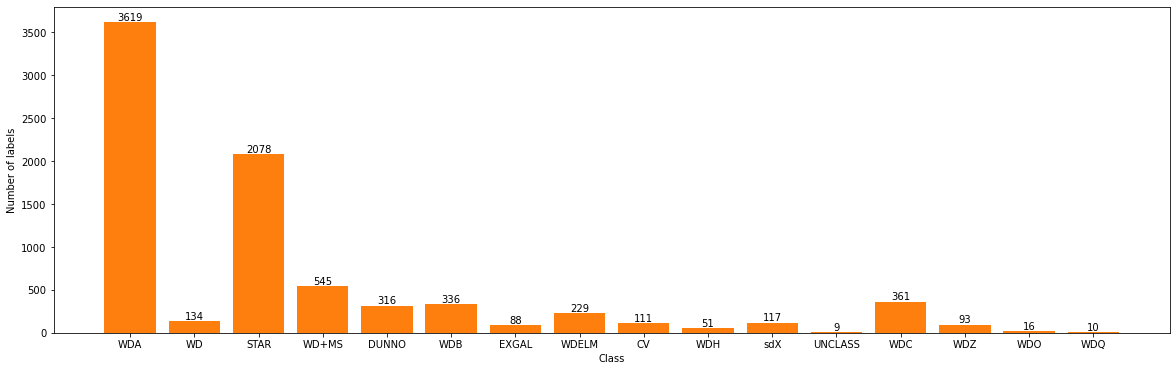

In [21]:
# Plot bar graph of labels

counter = Counter(star_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

In [22]:
# We should probably dismiss the only UNCLASS object.

star_df.drop(star_df.index[star_df['Classification'] == 'UNCLASS'], inplace = True)

## Spectroscopic Data

We will be working with the .dat files downloaded from SDSS5, rather than directly with the .fits files. For this simple example, we 

In [44]:
sdss_data_path = r'\\wsl$\Ubuntu\home\mafalsa\SDSSdata'
folder_list = os.listdir(sdss_data_path)


In [45]:
folder_list

['cb_cvcandidates',
 'cb_gaiagalex',
 'cb_uvex4',
 'boss_v6_0_4.csv',
 'cb_300pc',
 '250pc',
 'cb_uvex2',
 '100pc',
 'cb_uvex3',
 'cb_uvex5',
 'cb_uvex1',
 'wd']

In [50]:
# We have downloaded the SDSS5 data to the following folder.

sdss_data_path = r'\\wsl$\Ubuntu\home\mafalsa\SDSSdata'

# Let's use again, element 4553795050 as an example and see which .dat files associated to this object can we find.

Target_id = '4553795050'
folder_list = os.listdir(sdss_data_path)
for folder in folder_list:
    dat_files_path = os.path.join(sdss_data_path, folder)
    for filename in os.listdir(dat_files_path):
        if Target_id in filename and filename.endswith('.dat'):
            print(os.path.join(folder, filename))

cb_gaiagalex\SDSSJ073515.14+362444.7_15127-59190-0428_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15190-59273-0195_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15190-59248-0371_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15190-59267-0183_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15127-59190-0428_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15190-59273-0195_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15190-59248-0371_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15190-59267-0183_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat
wd\SDSSJ073515.14+362444.7_15127-59190-0428_4553795050.dat
wd\SDSSJ073515.14+362444.7_15190-59273-0195_4553795050.dat
wd\SDSSJ073515.14+362444.7_15190-59248-0371_4553795050.dat
wd\SDSSJ073515.14+362444.7_15190-59267-0183_4553795050.dat
wd\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat


We can see theres multiple .dat files, each associted with a different Modified Julian Date (MJD), for the same object. Lets plot one:

No handles with labels found to put in legend.


Text(0, 0.5, 'Flux')

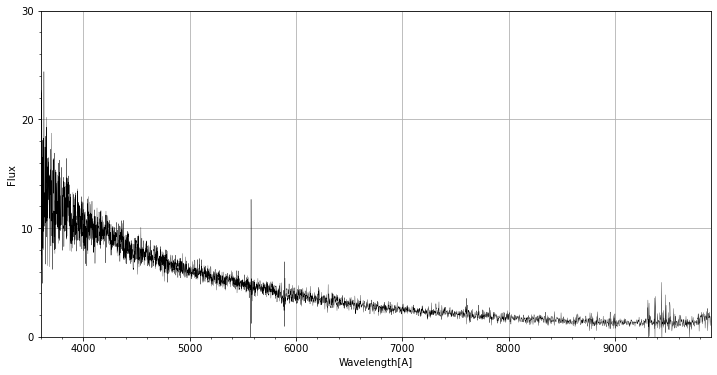

In [51]:
# Unpack SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat file and plot:

file_path = os.path.join(sdss_data_path, 'wd\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat')

sed = np.loadtxt(file_path, unpack = True)
wavelength = sed[0,:]
flux = sed[1,:]
ivar = sed[2,:]

fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(True)
ax.legend(frameon=False)
ax.plot(wavelength, (flux * 10 ** 17), linewidth=0.3, color='black')
ax.set_xlim([3600, 9900])
ax.set_ylim([0, 30])
ax.xaxis.set_minor_locator(plt.MultipleLocator(200))
ax.yaxis.set_minor_locator(plt.MultipleLocator(2))
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
plt.xlabel('Wavelength[A]')
plt.ylabel('Flux')


For our problem, the x feature will be the .dat data file, while de Y feature will be the class assgined. Lets build a dataframe with those features.

In [25]:
# This routine is way too inefficient, have to optimize it.

# file_list = os.listdir(sdss_data_path)
# spectrum_df1 = pd.DataFrame(columns=['filename', 'classID'])

# for index, row in star_df_final.iterrows():
#     found_flag = 0
#     for filename in file_list:
#         if str(row['Target ID']) in filename and str(row['MJD']) in filename:
#             spectrum_df1 = spectrum_df1.append({'filename' : filename, 'classID' : row['Classification']}, ignore_index=True)
#             found_flag = 1
#             break
#     if found_flag == 0:
#         print('file not found for MJD:{}, TID:{}'.format(row['MJD'], row['Target ID']))

In [61]:
# First process the files names to make a dict and take advantage of its
# hashed structure. Depends on data filename structure but way more efficient.


folder_list = os.listdir(sdss_data_path)
file_dict = dict()
for folder in folder_list:
    file_list = os.listdir(os.path.join(sdss_data_path, folder))
    for filename in file_list:
        if filename.endswith('.dat'):
            file_dict[filename.split('-')[-2] + '_' + filename.split('_')[-1]] = os.path.join(folder, filename)

spectrum_df = pd.DataFrame(columns=['filename', 'classID'])

for index, row in star_df.iterrows():
    filekey = str(row['MJD']) + '_' + str(row['Target ID']) + '.dat'
    if filekey in file_dict:
        spectrum_df = spectrum_df.append({'filename' : file_dict[filekey], 'classID' : row['Classification']}, ignore_index=True)

spectrum_df

,filename,classID
0,cb_uvex1\SDSSJ121828.50+300201.3_15249-59265-0204_4601916346.dat,WDA
1,wd\SDSSJ070928.42-115148.7_15086-59267-0068_4474143209.dat,WDA
2,wd\SDSSJ092633.22+031704.7_15266-59306-0129_4592699543.dat,WDA
3,wd\SDSSJ084230.03+014543.0_15165-59202-0055_4545012720.dat,WDA
4,wd\SDSSJ031251.58+530140.4_15221-59245-0050_4306649216.dat,WD
...,...,...
8087,cb_gaiagalex\SDSSJ180328.74+125336.5_15346-59300-0392_5208867797.dat,WD+MS
8088,wd\SDSSJ234641.07+005519.9_15034-59165-0447_4382235429.dat,WDC
8089,cb_uvex2\SDSSJ061822.95+413145.7_15288-59294-0114_4552859261.dat,STAR
8090,cb_gaiagalex\SDSSJ172450.01+775556.0_15370-59338-0361_4347784790.dat,STAR


In [62]:
pd.set_option("display.max_colwidth", -1)
spectrum_df

C:\Users\mafalsa\AppData\Local\Temp/ipykernel_12556/698098325.py:1: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option("display.max_colwidth", -1)


,filename,classID
0,cb_uvex1\SDSSJ121828.50+300201.3_15249-59265-0204_4601916346.dat,WDA
1,wd\SDSSJ070928.42-115148.7_15086-59267-0068_4474143209.dat,WDA
2,wd\SDSSJ092633.22+031704.7_15266-59306-0129_4592699543.dat,WDA
3,wd\SDSSJ084230.03+014543.0_15165-59202-0055_4545012720.dat,WDA
4,wd\SDSSJ031251.58+530140.4_15221-59245-0050_4306649216.dat,WD
...,...,...
8087,cb_gaiagalex\SDSSJ180328.74+125336.5_15346-59300-0392_5208867797.dat,WD+MS
8088,wd\SDSSJ234641.07+005519.9_15034-59165-0447_4382235429.dat,WDC
8089,cb_uvex2\SDSSJ061822.95+413145.7_15288-59294-0114_4552859261.dat,STAR
8090,cb_gaiagalex\SDSSJ172450.01+775556.0_15370-59338-0361_4347784790.dat,STAR


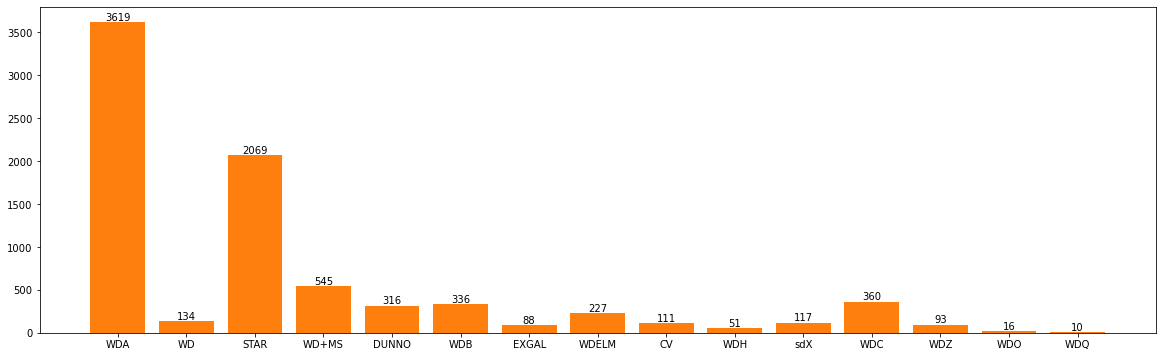

In [63]:
counter = Counter(spectrum_df['classID'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star classes using matplotlib

indexes = np.arange(len(star_class))
width = 0.7
fig, ax = plt.subplots(figsize=(20,6))
plt.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)
plt.xticks(indexes , star_class)
plt.show()

We can see that we are currently missing some .dat files, but for now, we can make a ML pipeline only for the available data, though we probabl;y want to explucde EXGAL class from classification. ALso, for now, let's drop the star class, as these are not WDs.

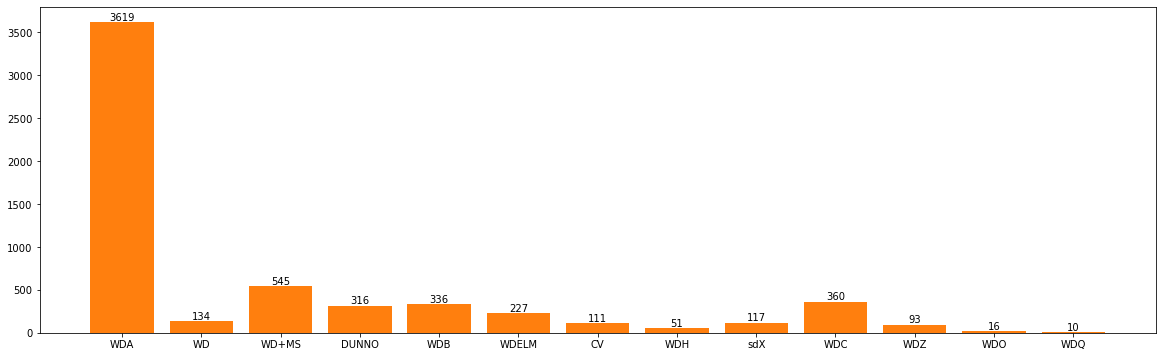

In [64]:
spectrum_df.drop(spectrum_df.index[spectrum_df['classID'] == 'EXGAL'], inplace = True)
spectrum_df.drop(spectrum_df.index[spectrum_df['classID'] == 'STAR'], inplace = True)
spectrum_df = spectrum_df.reset_index(drop=True)

counter = Counter(spectrum_df['classID'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star classes using matplotlib

indexes = np.arange(len(star_class))
width = 0.7
fig, ax = plt.subplots(figsize=(20,6))
plt.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)
plt.xticks(indexes , star_class)
plt.show()

Now that we have the spectrum data (represented en each .dat filename) and label data in a single dataframe, we will split this into two data sets: training dataset and testing dataset. 

## Test and trainig sets.

First, we must divide our available data in test a training sets

In [66]:
# just for checking all data files have the same flux and wavelenght length, 4648.

for index, filename in spectrum_df['filename'].iteritems():
    sed = np.loadtxt(filename, unpack = True)
    wavelength = sed[0,:]
    flux = sed[1,:]
    ivar = sed[2,:]
    if len(flux) + len(wavelength) != (4648 + 4648):
        print(index, filename, len(flux), len(wavelength))

In [31]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(spectrum_df, spectrum_df["classID"]):
    strat_train_set = spectrum_df.loc[train_index]
    strat_test_set = spectrum_df.loc[test_index]


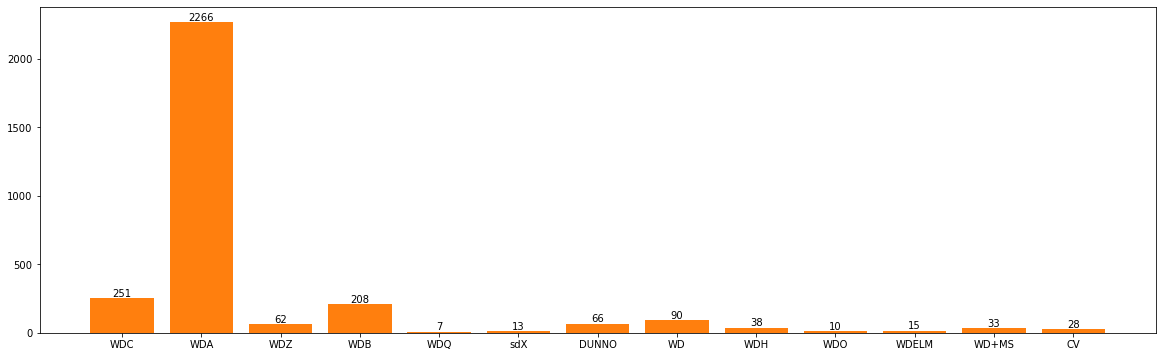

In [32]:
counter = Counter(strat_train_set['classID'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star classes using matplotlib

indexes = np.arange(len(star_class))
width = 0.7
fig, ax = plt.subplots(figsize=(20,6))
plt.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)
plt.xticks(indexes , star_class)
plt.show()

We want to load a matrix from the training set, normalizing around a centro frequency. We will also discard the tails of the data (where there is usually high noise and no feature should be important). Playing around with a particular wavelenght, i decided to cut the data to wavelength[48:-400] (3605 - 9477 [A] app) and normalize the data around the element 2100 (5847 [A] app). The resulting lenght of the arrays is 4200.

We will also use hot encoding for the labels of each file

In [33]:
# Hot encoding dictionary
counter = Counter(strat_train_set['classID'])
star_class = counter.keys()

stars_encoding = dict()
star_class = list(star_class)
num_classes = len(star_class)


for label in star_class:
    code = np.zeros(num_classes)
    code[star_class.index(label)] = 1
    stars_encoding[label] = code
print(stars_encoding, len(stars_encoding))

{'WDC': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDA': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDZ': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDB': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDQ': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]), 'sdX': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), 'DUNNO': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'WD': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]), 'WDH': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]), 'WDO': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), 'WDELM': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), 'WD+MS': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), 'CV': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])} 13


In [39]:
# We want to load a matrix from the training data, given the data size this wil be acceptable.

train_matrix = np.empty((0,4200), float)
label_matrix = np.empty((0, len(star_class)), float)

for index, row in strat_train_set.iterrows():
    file_path = os.path.join(sdss_data_path, row['filename'])
    sed = np.loadtxt(file_path, unpack = True)
    wavelength = sed[0,48:-400]
    flux = sed[1,48:-400]
    flux = np.divide(flux, flux[2100])
    if(np.isnan(flux).any() or np.isnan(wavelength).any()):
        print('Nan data found')
    else:
        train_matrix = np.append(train_matrix, np.transpose(flux[:, None]), axis=0)
        label_matrix = np.append(label_matrix, np.transpose(stars_encoding[row['classID']][:, None]), axis=0)

C:\Users\mafalsa\AppData\Local\Temp/ipykernel_12556/1471053931.py:11: RuntimeWarning: invalid value encountered in true_divide
  flux = np.divide(flux, flux[2100])


Nan data found
Nan data found
Nan data found
Nan data found
Nan data found
Nan data found
Nan data found
Nan data found
Nan data found


In [40]:
print(train_matrix.nbytes, train_matrix.shape)
print(label_matrix.nbytes, label_matrix.shape)

103420800 (3078, 4200)
320112 (3078, 13)


Now we have loaded both the train matrix with training data (the spectrums data after pre-processing) and the label matrix wich contains the associated label data (class of each star hot encoded) as numpy arrays. The size of the matrices is small enough for a personal computer in most cases. Now, we'll proceed doing a grid search over different parameters
 of an artificial neural network (ANN) using keras.

### A note on K-Fold Cross validation

For this first approach, we will not be implementing K-Fold cross validation for splitting the training set into smaller training and validations set in an iterative way. This is very useful, but is time consuming and requires more data from the under represented classes (a problem we will takle using some Data Augmentation strategy), and so is not suited for this simple demonstration. One important note is that, when K-Fold Cross validation is implemented, we should modify the default python funtions we'll use (most liekly from scikit-learn) so as to consider the fact that we are wroking on an imbalanced set.

# Building an ANN in keras

In [41]:
# First we'll define a class weight dictionary
from sklearn.utils.class_weight import compute_class_weight

y_integers = np.argmax(label_matrix, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_integers), y=y_integers)
d_class_weights = dict(enumerate(class_weights))
print(d_class_weights)

{0: 0.947076923076923, 1: 0.10462626193956287, 2: 3.8814627994955866, 3: 1.1383136094674555, 4: 33.824175824175825, 5: 18.21301775147929, 6: 3.8188585607940446, 7: 2.6307692307692307, 8: 6.230769230769231, 9: 23.676923076923078, 10: 15.784615384615385, 11: 7.174825174825175, 12: 8.456043956043956}


In [43]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
opt = SGD(lr=0.05)

model = Sequential([Dense(4200, input_dim = 4200, activation='relu', kernel_initializer='uniform'),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dense(13, activation='softmax', kernel_initializer='uniform')])

# opt = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(train_matrix, label_matrix, batch_size=64, epochs=100, class_weight=d_class_weights)

Epoch 1/100
49/49 [==============================] - 3s 63ms/step - loss: 3.2274 - accuracy: 0.1507
Epoch 2/100
49/49 [==============================] - 3s 63ms/step - loss: nan - accuracy: 0.0604                              
Epoch 3/100
49/49 [==============================] - 3s 62ms/step - loss: nan - accuracy: 0.0812
Epoch 4/100
49/49 [==============================] - 3s 62ms/step - loss: nan - accuracy: 0.0812
Epoch 5/100
49/49 [==============================] - 3s 62ms/step - loss: nan - accuracy: 0.0812
Epoch 6/100
49/49 [==============================] - 3s 62ms/step - loss: nan - accuracy: 0.0812
Epoch 7/100
49/49 [==============================] - 3s 67ms/step - loss: nan - accuracy: 0.0812
Epoch 8/100
49/49 [==============================] - 3s 57ms/step - loss: nan - accuracy: 0.0812
Epoch 9/100
49/49 [==============================] - 3s 59ms/step - loss: nan - accuracy: 0.0812
Epoch 10/100
49/49 [==============================] - 2s 47ms/step - loss: nan - accuracy: 0.0

Now that we have trained the model, we can see it's metrics

In [ ]:
from sklearn.metrics import confusion_matrix

train_sample_output = model.predict(train_matrix, batch_size=60)

36/36 [==============================] - 1s 16ms/step


In [ ]:
predict_class = np.argmax(train_sample_output, axis=1)
actual_class = np.argmax(label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class)

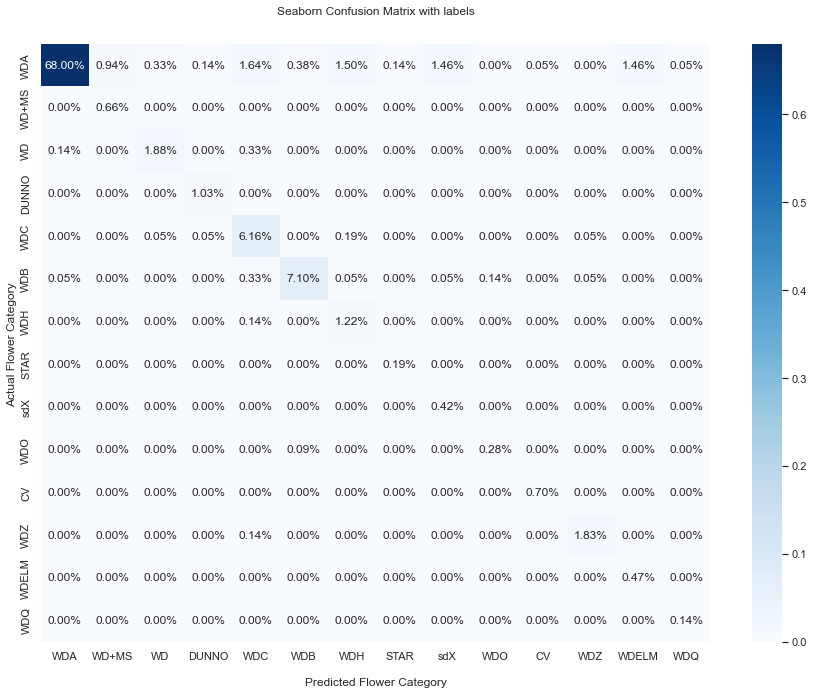

In [ ]:
import seaborn as sns

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, 
            fmt='.2%', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Flower Category')
ax.set_ylabel('Actual Flower Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1,11)
plt.plot(epochs, loss_train, 'g', label='Training accuracy')
plt.plot(epochs, loss_val, 'b', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

KeyError: 'val_accuracy'

In [ ]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1,35)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print(history.history.keys())


dict_keys(['loss', 'accuracy'])
